# This script produces schematics of structrual connectivity with FST based on a literature review.

### The figures are dynamic, and can be changed to visualized for
species = "macaque" or "human" \
    roiCoarse = no  (shows very fine or very general regions)
roi = "FST" or "MST" or "MT"   \
displaybrain = yes

if displaybrain == no \
    rotateon    = yes (is read only when displaybrain == no); will rotate the hierachy to be vertical \
    medial      = yes (is read only when displaybrain == no); will additionally plot medial side \
    subcortical = yes (is read only when displaybrain == no); will additionally plot subcortical

### All the details about the sources of this information is summarized in
citations.txt (abbreviations will appear on figure when hovering)

### The logic used for the connections are as follows:

1. Not all cortical regions are displayed here. Regions are chosen based on regions reportedly connected to one or more motion cluster areas identified in the literature review. When visualizing, with roi = "FST", for example, you may find a given area has no connections with FST, despite being visible--this means this region connects with one or more motion cluster areas but not FST.
2. Solid lines indicate: at least one physiology measurment, and uncontroversial relation.
   Dashed lines indicate: mixed evidence (some find a relation, some find no relation, areal heterogeneity,
   Dotted lines indicate ONLY indirect evidence such as diffusion MRI, or subdivision not specified--e.g., FST --> MST rather than FST --> MSTd and FST --> MSTv would count as indirect).
3. Line thickness indicates the strength of evidence (# of total studies reporting the connection, irrspective of direct/mixed/indirect)
\
\
Note for macaque: if the only conflict is due to Felleman & Van Essen 91, this conflict is disregarded because the motion cluster regions are less in agreement with contemporary atlases. For example, FST is grossly more anterior in Fel91 atlas compared to other atlases (Lewis & Van Essen 2000, Ungerleider & Desimone 86, and Kolster et al. 2009).

### ROI grouping can be set to coarse, or fine.

The ROIs selected were combined across several studies, which use different regional definitions. These are approximated to match those that we use here, but we add the citation to appear when hovering to provide the direct source for more exact areal boundaries in each respective method.

### Might add in future

Arrows have not been added to indicate feedforward or feedback, but this can be an added feature. Most connections with FST in particular seem to be bidirectional. 
\
Important information about the relative weight of the connection from either FST, MST, and MT to all other areas. For example, although both FST and MST might connect to parietal areas, perhaps it is moreso the case for MST. This is not captured in this data.

In [1]:
# # TO DO:
           # # image size: 2250 x 1325
# Add option to rotate with BOXES:
# 	-lines would need re-routes?

# Subcortical connection and medial

# Do human

In [2]:
# import pandas as pd
# import networkx as nx
# import matplotlib.pyplot as plt
# import matplotlib.image as mpimg
# from PIL import Image

# # Load data
# nodes_df = pd.read_csv("nodes.csv")
# edges_df = pd.read_csv("edges.csv")

# # Create directed graph
# G = nx.DiGraph()

# # Add nodes
# for _, row in nodes_df.iterrows():
#     G.add_node(
#         row["id"],
#         pos=(row["x"], row["y"]),
#         label=row["label"],
#         color=row["color"],
#         size=row["size"]
#     )

# # Add directed edges (respect direction column)
# for _, row in edges_df.iterrows():
#     if row["direction"] == "forward":
#         G.add_edge(row["Source"], row["target"], weight=row["weight"])
#     elif row["direction"] == "backward":
#         G.add_edge(row["target"], row["Source"], weight=row["weight"])
#     else:
#         G.add_edge(row["target"], row["Source"], weight=row["weight"])

# # Extract positions
# positions = {n: G.nodes[n]['pos'] for n in G.nodes}

# # Load your background image
# background_img = mpimg.imread("./macaque_surfaces/veryinflated_lat.tif")

# # Plot overlay
# plt.imshow(background_img)
# # for u, v in G.edges():
# #     x0, y0 = positions[u]
# #     x1, y1 = positions[v]
# #     plt.arrow(x0, y0, x1-x0, y1-y0,
# #               color='black', width=2, head_width=12, alpha=0.7,
# #               length_includes_head=True)
# plt.scatter(
#     [positions[n][0] for n in G.nodes],
#     [positions[n][1] for n in G.nodes],
#     s=[G.nodes[n]['size']*15 for n in G.nodes],
#     color=[G.nodes[n]['color'] for n in G.nodes],
# #    edgecolor='black'
# )
# for n in G.nodes:
#     x, y = positions[n]
#     plt.text(x-35, y+30, G.nodes[n]['label'], fontsize=8, color='black')
# plt.axis('off')
# plt.show()



In [3]:
# imgpath = os.path.join("/Users/rje257/Documents/GitHub/grating_model/tutorials/", "macaque", "surface_snapshots", "veryinflated_montage_nolabels_subcort.tif")

# img = Image.open(imgpath)
# [figheight, figwidth, nch] = np.shape(img)
# figheight = int(figheight/2)
# figwidth = int(figwidth/2)
# print(figwidth*2)
# print(figheight*2)

In [24]:
import pandas as pd
import plotly.graph_objects as go
from PIL import Image
import os
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import numpy as np

def plotConnectivity(species, roi="FST", roicoarse=0, displaybrain=1, rotateon=0, medial=0, subcortical=0):

    # load image regardless because it is the basis of the coordinate system, which differs between species
    if medial==1:
        imgpath = os.path.join("/Users/rje257/Documents/GitHub/CorticalConnectivity/", species, "surface_snapshots", "veryinflated_montage_nolabels_subcort.tif")
        if species=="macaque":
            shiftFactorX = 2
            shiftFactorY = 0.75
        else:
            shiftFactorX = 1.8    # these can be adjusted to shift
            shiftFactorY = 0.85
    else:
        imgpath = os.path.join("/Users/rje257/Documents/GitHub/CorticalConnectivity/", species, "surface_snapshots", "veryinflated_lat_white.tif")
        # original macaque measures used figwidth/height of 900x600 instead of int(1125/2) x int(663/2).
        # to get medial==0 for macaque to recover back to normal, scale all values to account for this.
        shiftFactorX = 1
        shiftFactorY = 1
    
    img = Image.open(imgpath)
    [figheight, figwidth, nch] = np.shape(img)
    figheight = int(figheight/2)
    figwidth = int(figwidth/2)

    print(figwidth)
    print(figheight)
    
    nodes_df = pd.read_csv(os.path.join(species,"nodes.csv"))
    edges_df = pd.read_csv(os.path.join(species,"edges.csv"))
    
    # --- Extract node info ----
    ydim = int(np.floor(np.shape(img)[0]/2*shiftFactorY))
    xdim = int(np.floor(np.shape(img)[1]/2*shiftFactorX))
    
    node_x = [(x - xdim) for x in nodes_df['x'].tolist()]
    node_y = [(y - ydim) * -1 for y in nodes_df['y'].tolist()]

    node_labels = nodes_df['label'].tolist()
    node_colors = nodes_df['color'].tolist()
    node_comments = nodes_df[f'{roi}comments'].tolist()
    node_sizes  = [s * 3 for s in nodes_df['size'].tolist()]
    
    # quick id -> index lookup
    id_to_idx = {idv: i for i, idv in enumerate(nodes_df['id'].tolist())}
    
    edge_traces = []
    for _, row in edges_df.iterrows():
        src = row['Source']
        tgt = row['target']
        w   = float(row['weight'])
        dash_style = "dash" if row["conflicting"] == 1 else "solid"

        # feedback/feedforward color
        direction = row["direction"]  # <-- read column
        if direction == "intermediate":
            edge_color = "grey" #"#777"
        elif direction == "feedforward":
            edge_color = "black"
        elif direction == "feedback":
            edge_color = "white"
        else:
            edge_color = "grey" #"#777"    # for mixed (some say feedforward, some say feedback)
        
        i0 = id_to_idx[src]
        i1 = id_to_idx[tgt]
    
        x0, y0 = node_x[i0], node_y[i0]
        x1, y1 = node_x[i1], node_y[i1]
    
        # look up positions
        # x0 = nodes_df.loc[nodes_df['id'] == src, 'center_x'].values[0]
        # y0 = nodes_df.loc[nodes_df['id'] == src, 'center_y'].values[0]
        # x1 = nodes_df.loc[nodes_df['id'] == tgt, 'center_x'].values[0]
        # y1 = nodes_df.loc[nodes_df['id'] == tgt, 'center_y'].values[0]
    
        edge_traces.append(
            go.Scatter(
                x=[x0, x1],
                y=[y0, y1],
                mode="lines",
                hovertext='testing', #f"Connection: {src} → {tgt}<br>",
                hoverinfo="text",
                line=dict(color=edge_color, width=w*3, dash=dash_style), #color="#777"
            )
        )
    
    # -------- Plot nodes --------
    node_trace = go.Scatter(
        x=node_x,
        y=node_y,
        mode='markers+text',
        text=node_labels,
        textposition="top center",
        hovertext=node_comments, #f"Connection: {src} → {tgt}<br>",
        hoverinfo="text",
        marker=dict(
            color=node_colors,
            size=node_sizes,
            line_width=1,
            line_color="black"
        )
    )
    
    fig = go.Figure(
        data=edge_traces + [node_trace],
        layout=go.Layout(
            width=figwidth,
            height=figheight,
            title=f"{species} {roi} Connections",
            showlegend=False,
            hovermode='closest',
            margin=dict(b=0, l=0, r=0, t=0),
            #margin=dict(b=20, l=20, r=20, t=40),
            xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
            yaxis=dict(showgrid=False, zeroline=False, showticklabels=False)
        )
    )

    if displaybrain==1:
        fig.add_layout_image(dict(
            source=img, x=0, y=1, sizex=1, sizey=1,
            xref="paper", yref="paper", sizing="contain", layer="below"
        ))
    
    fig.update_layout(plot_bgcolor="black")

    if medial==1:
        #if species=="macaque":
        fig.update_xaxes(scaleanchor="y", scaleratio=1, range=[-50, 50])
        fig.update_yaxes(range=[-1*(figheight*2), figheight*2])
        # else:
        #     fig.update_xaxes(scaleanchor="y", scaleratio=1, range=[-100, 100])
        #     fig.update_yaxes(range=[-1*(figheight*2), figheight*2])
    else:   # added this when making human
        fig.update_xaxes(scaleanchor="x", scaleratio=1, range=[-1*(figwidth), figwidth])
        fig.update_yaxes(range=[-1*(figheight), figheight])
        

    fig.show()


877
884


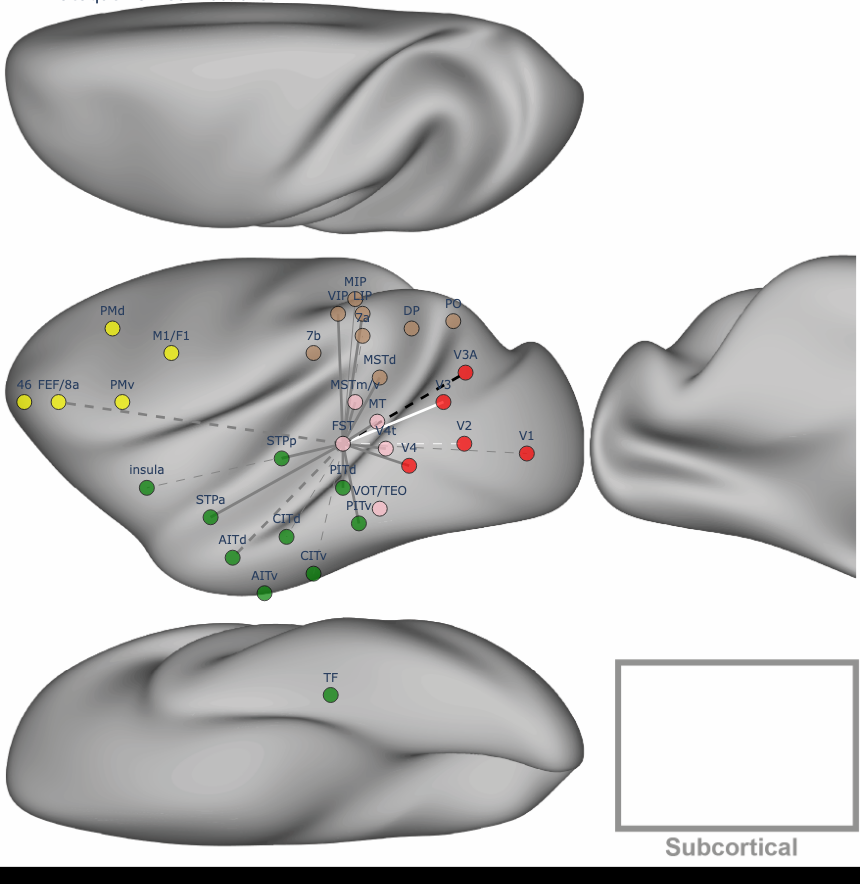

In [25]:
plotConnectivity("macaque", "FST", displaybrain=1, medial=1, subcortical=1)


# MACAQUE
# cannot show TF, TH (too ventral/medial)
# cannot show PIP, PO (V6/V6A), MDP (7m), medial parietal (BA 23, RSC, BA 31)

# HUMAN
# cannot show V6 (too medial), RSC


# species = "macaque" or "human"
# roiCoarse = no (shows very fine or very general regions) roi = "FST" or "MST" or "MT"
# displaybrain = yes

# if displaybrain == no
# rotateon = yes (is read only when displaybrain == no); will rotate the hierachy to be vertical
# medial = yes (is read only when displaybrain == no); will additionally plot medial side
# subcortical = yes (is read only when displaybrain == no); will additionally plot subcortical

In [414]:
xdim

1125

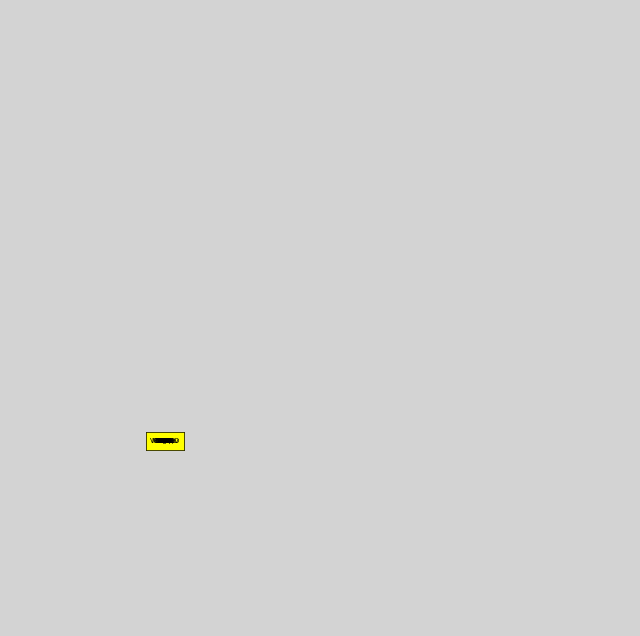

In [198]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Load CSV
nodes_df = pd.read_csv("nodes.csv")

# ---- Square figure ----
fig_size = 8  # inches
fig, ax = plt.subplots(figsize=(fig_size, fig_size))
fig.patch.set_facecolor("lightgrey")   # or "#d9d9d9", "0.8", etc.

# ---- Fixed box size (percent of figure) ----
box_w = 0.06    # width  = 8% of figure
box_h = 0.03    # height = 5% of figure

for _, row in nodes_df.iterrows():

    # Convert center to top-left corner
    x1 = row['center_x'] - box_w / 2
    y1 = row['center_y'] - box_h / 2

    # Draw rectangle
    rect = patches.Rectangle(
        (x1, y1),
        box_w,
        box_h,
        transform=ax.transAxes,
        linewidth=0.4,
        edgecolor='black',
        facecolor=row['color']   # box color from CSV
    )
    ax.add_patch(rect)

    # Draw label at center
    ax.text(
        row['center_x'],
        row['center_y'],
        row['label'],
        transform=ax.transAxes,
        ha='center',
        va='center',
        fontsize=row['size'],
        color='black'
    )

# ---- Clean visual settings ----
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.invert_yaxis()   # optional: makes (0,0) the top-left
ax.axis("off")

plt.show()

#(0.0, 0.0) = bottom-left corner (1,1) = top right

In [200]:
import plotly.graph_objects as go
import plotly.graph_objects as go
import networkx as nx

G = nx.random_geometric_graph(200, 0.125)

print(len(G.nodes))   # number of nodes
print(len(G.edges))   # number of edges
print(list(G.nodes)[:5])  # first few node IDs
print(list(G.edges)[:5])  # first few edges
print(G.nodes[0])

#G.nodes[0]['pos'] = (0.6, 0.4)
G.nodes[0]['label'] = 'Neuron A'

G = nx.DiGraph(G)

200
809
[0, 1, 2, 3, 4]
[(0, 12), (0, 25), (0, 61), (0, 68), (0, 86)]
{'pos': [0.8178116371417781, 0.9723591825549276]}


200
849
[0, 1, 2, 3, 4]
[(0, 38), (0, 100), (0, 125), (0, 148), (0, 153)]
{'pos': [0.8358188549579413, 0.9892400305652006]}
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199


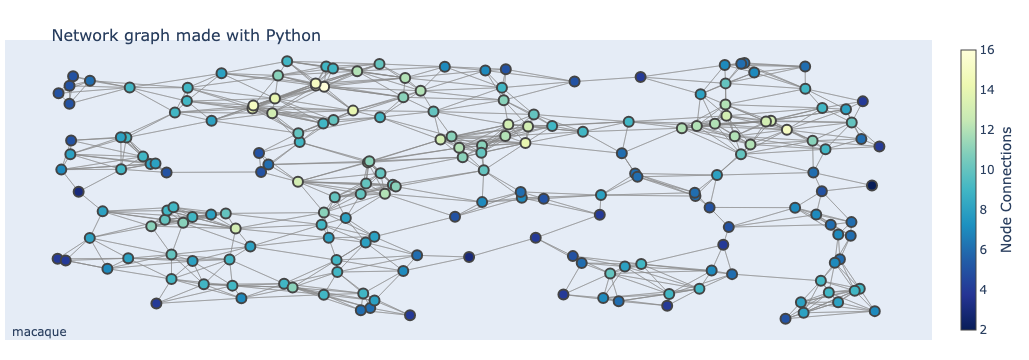

In [208]:
import plotly.graph_objects as go
import plotly.graph_objects as go
import networkx as nx

G = nx.random_geometric_graph(200, 0.125)

print(len(G.nodes))   # number of nodes
print(len(G.edges))   # number of edges
print(list(G.nodes)[:5])  # first few node IDs
print(list(G.edges)[:5])  # first few edges
print(G.nodes[0])

#G.nodes[0]['pos'] = (0.6, 0.4)
G.nodes[0]['label'] = 'Neuron A'

G = nx.DiGraph(G)

edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = G.nodes[edge[0]]['pos']
    x1, y1 = G.nodes[edge[1]]['pos']
    edge_x.append(x0)
    edge_x.append(x1)
    edge_x.append(None)
    edge_y.append(y0)
    edge_y.append(y1)
    edge_y.append(None)

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
for node in G.nodes():
    x, y = G.nodes[node]['pos']
    node_x.append(x)
    node_y.append(y)

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    marker=dict(
        showscale=True,
        # colorscale options
        #'Greys' | 'YlGnBu' | 'Greens' | 'YlOrRd' | 'Bluered' | 'RdBu' |
        #'Reds' | 'Blues' | 'Picnic' | 'Rainbow' | 'Portland' | 'Jet' |
        #'Hot' | 'Blackbody' | 'Earth' | 'Electric' | 'Viridis' |
        colorscale='YlGnBu',
        reversescale=True,
        color=[],
        size=10,
        colorbar=dict(
            thickness=15,
            title=dict(
              text='Node Connections',
              side='right'
            ),
            xanchor='left',
        ),
        line_width=2))

node_adjacencies = []
node_text = []
for node, adjacencies in enumerate(G.adjacency()):
    node_adjacencies.append(len(adjacencies[1]))
    node_text.append('# of connections: '+str(len(adjacencies[1])))

for node, ni in enumerate(G.nodes):
    print(node)
    #node_text.append(G.nodes[ni]['label'])

node_trace.marker.color = node_adjacencies
node_trace.text = node_text

fig = go.Figure(data=[edge_trace, node_trace],
             layout=go.Layout(
                title=dict(
                    text="<br>Network graph made with Python",
                    font=dict(
                        size=16
                    )
                ),
                showlegend=False,
                hovermode='closest',
                margin=dict(b=20,l=5,r=5,t=40),
                annotations=[ dict(
                    text="macaque",
                    showarrow=False,
                    xref="paper", yref="paper",
                    x=0.005, y=-0.002 ) ],
                xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
                yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
                )
fig.show()

In [5]:
edge_trace

Scatter({
    'hoverinfo': 'none',
    'line': {'color': '#888', 'width': 0.5},
    'mode': 'lines',
    'x': [0.014383076569224773, 0.029046029018770847, None, ...,
          0.9643175716257575, 0.9054426699380129, None],
    'y': [0.08384831364246625, 0.04720627056697024, None, ..., 0.7537892530877334,
          0.7690082821531924, None]
})

In [3]:
########################

import pandas as pd
from pyvis.network import Network


In [5]:
#Loading the data
data = pd.read_csv("facebook_combined.txt", sep=" ", header=None)
data.columns = ["person1", "person2"]
sample = data.sample(1000, random_state = 1)
sample.head(10)

,person1,person2
74346,2839,3064
62630,2309,2590
199,0,200
51398,2088,2468
27375,1319,1568
37813,1741,1809
83696,3460,3761
17028,1029,1613
82498,3332,3355
2472,107,1699


In [6]:
net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
)
nodes = list(set([*sample.person1,*sample.person2]))
edges = sample.values.tolist()
net.add_nodes(nodes)
net.add_edges(edges)
net.show("graph.html")

graph.html


In [9]:
net = Network(notebook = True, cdn_resources = "remote",
                bgcolor = "#222222",
                font_color = "white",
                height = "750px",
                width = "100%",
                select_menu = True,
                filter_menu = True,
)
nodes = list(set([*sample.person1,*sample.person2]))
edges = sample.values.tolist()
net.add_nodes(nodes)
net.add_edges(edges)
net.show("graph_with_menu.html")

graph_with_menu.html


In [10]:
net.show_buttons(filter=”physics”)

SyntaxError: invalid character '”' (U+201D) (2446666336.py, line 1)

In [8]:
from jaal.datasets import load_got
#load the data
edge_df, node_df = load_got()
#init Jaal and run server
Jaal(edge_df, node_df).plot()

/opt/miniconda3/envs/viz/lib/python3.13/site-packages/dash_bootstrap_components/_table.py:5: UserWarning: 
The dash_html_components package is deprecated. Please replace
`import dash_html_components as html` with `from dash import html`
  import dash_html_components as html


NameError: name 'Jaal' is not defined

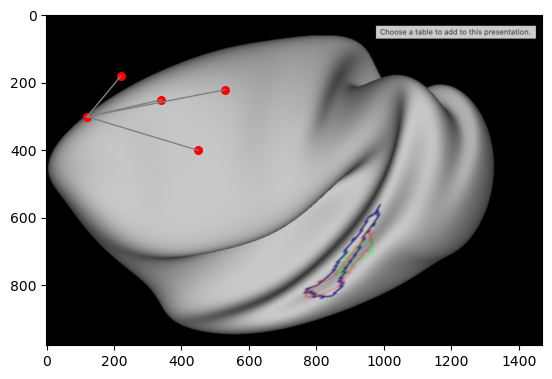

In [29]:
import sknetwork
import numpy as np
from scipy import sparse
from sknetwork.visualization import svg_graph
from IPython.display import SVG, display
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

edges = [
    [0, 1],
    [0, 2],
    [0, 3],
    [0, 4],
]

edges = np.array(edges)  # convert list → numpy array
rows, cols = edges.T     # now works

n_nodes = 5
data = np.ones(len(edges))
adjacency = sparse.coo_matrix((data, (rows, cols)), shape=(n_nodes, n_nodes))
adjacency = adjacency # + adjacency.T  # make it undirected

# adjacency is your graph (scipy sparse matrix or numpy array)
image_svg = svg_graph(adjacency,
                      position=positions,
                      node_size=10,
                      edge_width=1,
                      height=600, width=800)

#display(SVG(image_svg))

background_img = mpimg.imread("testsurface.png")

plt.imshow(background_img)
for i, j in zip(*adjacency.nonzero()):
    x0, y0 = positions[i]
    x1, y1 = positions[j]
    plt.plot([x0, x1], [y0, y1], color='gray', lw=1)
plt.scatter(positions[:,0], positions[:,1], color='red', s=30)
#plt.show()

In [28]:
adjacency

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 8 stored elements and shape (5, 5)>

In [26]:
edges

array([[0, 1],
       [1, 2],
       [2, 3],
       [3, 4],
       [4, 0]])

In [ ]:
# criteria for node graph:

# ability to make directed (arrows)
# ability to filter (only connections to and from one node, or multiple nodes, or common connections for node A and node B)
# ability to overlay on an image
# ability to set positions; or centers of gravity for clusters
# ability to add text label to each node